In [108]:
[1,2]+[3,4]

[1, 2, 3, 4]

In [109]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

In [110]:
DATA_PATH = Path("../data/raw/train_FD001.txt")
column_names = (
    ['engine_id', 'cycle']
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

In [111]:
df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

In [112]:
df.head(4)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739


In [113]:
df.describe()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [114]:
df.isna().sum()

engine_id    0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64

In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
df['engine_id'].nunique()

100

In [117]:
pd.DataFrame(df.groupby('engine_id'))

,0,1
0,1,engine_id cycle setting_1 setting_2 s...
1,2,engine_id cycle setting_1 setting_2 s...
2,3,engine_id cycle setting_1 setting_2 s...
3,4,engine_id cycle setting_1 setting_2 s...
4,5,engine_id cycle setting_1 setting_2 ...
...,...,...
95,96,engine_id cycle setting_1 setting_2 ...
96,97,engine_id cycle setting_1 setting_2 ...
97,98,engine_id cycle setting_1 setting_2 ...
98,99,engine_id cycle setting_1 setting_2 ...


In [118]:
engine_lifetimes = df.groupby('engine_id')['cycle'].max()
type(engine_lifetimes), engine_lifetimes.head()

(pandas.Series,
 engine_id
 1    192
 2    287
 3    179
 4    189
 5    269
 Name: cycle, dtype: int64)

In [119]:
engine_1 = df[df.engine_id==1]
engine_1.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [120]:
engine_1.tail()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,520.08,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649


In [121]:
print(df.shape)
print((df["engine_id"].nunique()))
print(engine_lifetimes.head(10))
print(df.isna().sum())

(20631, 26)
100
engine_id
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64
engine_id    0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64


In [122]:
df.columns

Index(['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7',
       'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17',
       'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='str')

In [123]:
df['max_cycle'] = df['engine_id'].map(engine_lifetimes)
df['rul'] = df['max_cycle'] - df['cycle']

In [124]:
df.head(5)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [125]:
df[df["engine_id"] == 1][["engine_id", "cycle", "max_cycle", "rul"]].head()

,engine_id,cycle,max_cycle,rul
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [126]:
df[df["engine_id"] == 1][["engine_id", "cycle", "max_cycle", "rul"]].tail()

,engine_id,cycle,max_cycle,rul
187,1,188,192,4
188,1,189,192,3
189,1,190,192,2
190,1,191,192,1
191,1,192,192,0


In [127]:
df.nunique().sort_values()

sensor_18       1
sensor_10       1
setting_3       1
sensor_1        1
sensor_19       1
sensor_16       1
sensor_5        1
sensor_6        2
setting_2      13
sensor_17      13
sensor_8       53
sensor_13      56
max_cycle      66
engine_id     100
sensor_20     120
setting_1     158
sensor_11     159
sensor_2      310
rul           362
cycle         362
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

In [128]:
unique_counts = df.nunique()
unique_counts[unique_counts<=10]

setting_3    1
sensor_1     1
sensor_5     1
sensor_6     2
sensor_10    1
sensor_16    1
sensor_18    1
sensor_19    1
dtype: int64

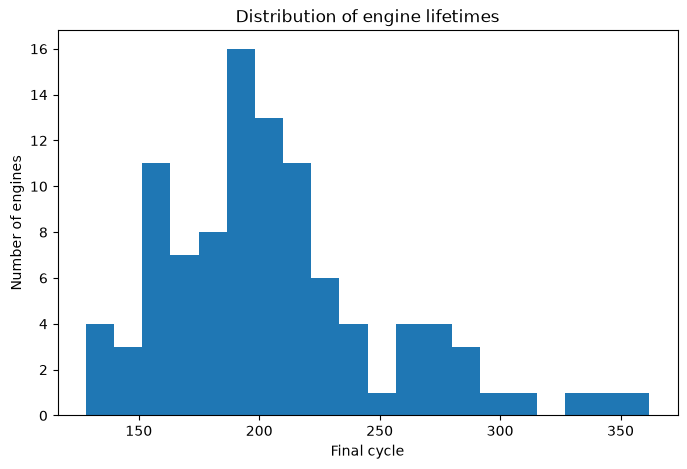

In [129]:
plt.figure(figsize=(8,5))
plt.hist(engine_lifetimes, bins=20)
plt.xlabel('Final cycle')
plt.ylabel('Number of engines')
plt.title('Distribution of engine lifetimes')
plt.show()

Text(0, 0.5, 'Cycle')

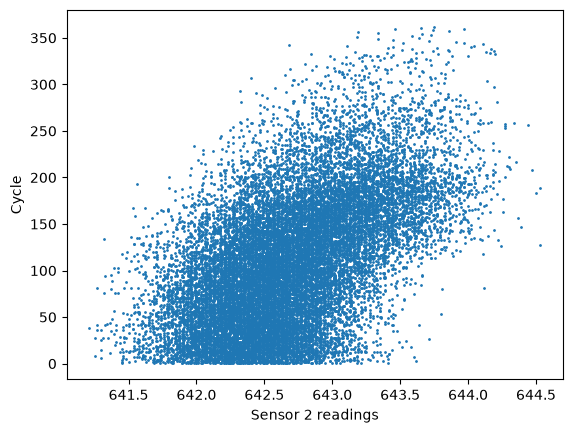

In [130]:
plt.scatter(df['sensor_2'], df['cycle'],s=1)
plt.xlabel('Sensor 2 readings')
plt.ylabel("Cycle")

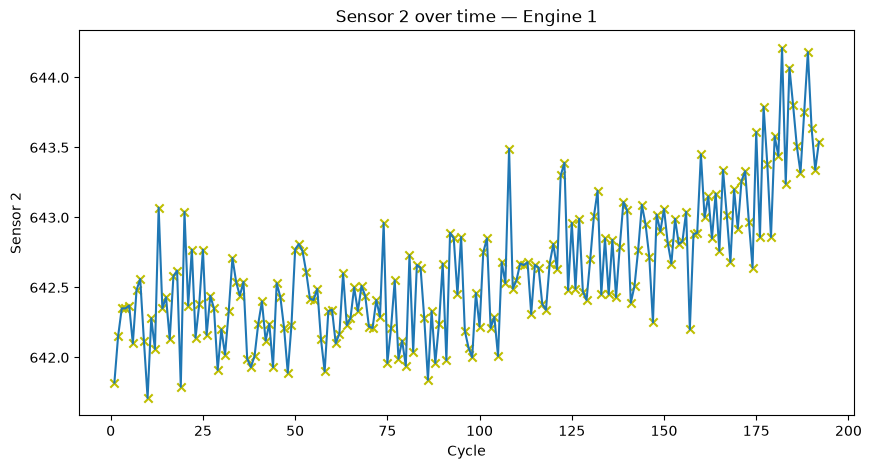

In [131]:
plt.figure(figsize=(10, 5))
plt.plot(engine_1["cycle"], engine_1["sensor_2"])

plt.scatter(engine_1["cycle"], engine_1["sensor_2"], c='y', marker='x')

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Sensor 2 over time — Engine 1")
plt.show()

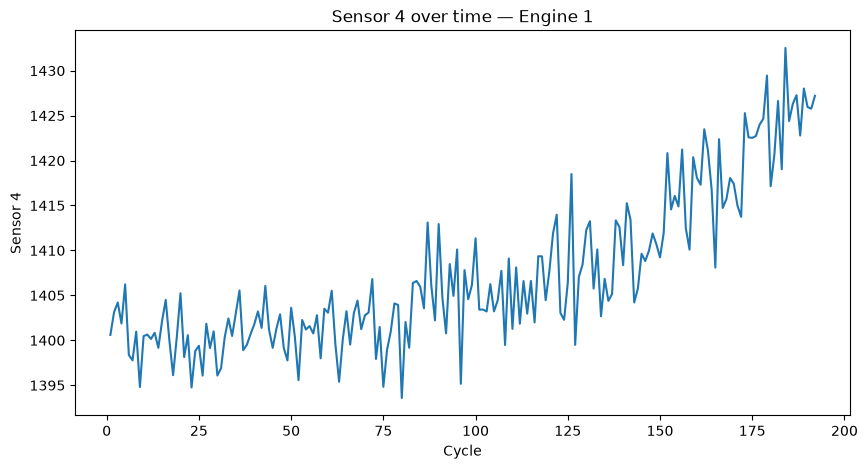

In [132]:
plt.figure(figsize=(10, 5))
plt.plot(engine_1["cycle"], engine_1["sensor_4"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 4")
plt.title("Sensor 4 over time — Engine 1")
plt.show()

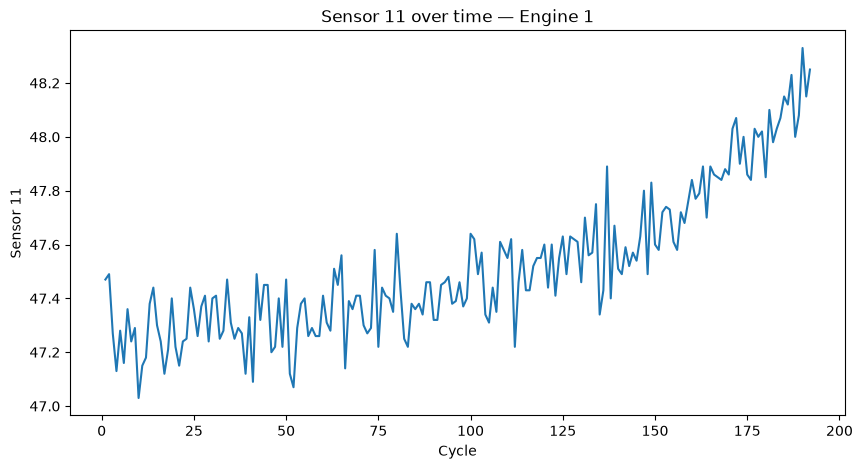

In [133]:
plt.figure(figsize=(10, 5))
plt.plot(engine_1["cycle"], engine_1["sensor_11"])
plt.xlabel("Cycle")
plt.ylabel("Sensor 11")
plt.title("Sensor 11 over time — Engine 1")
plt.show()

In [134]:
def plot_all_sensors(df, engine_id):
    """
    Plot all sensor readings over time for a given engine.

    Parameters
    ----------
    df : pandas.DataFrame
        C-MAPSS dataframe containing engine_id, cycle, and sensor columns.

    engine_id : int
        ID of the engine whose sensor history should be plotted.
    """
    import matplotlib.pyplot as plt

    engine_data = df[df["engine_id"] == engine_id]

    sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

    fig, axes = plt.subplots(
        nrows=7,
        ncols=3,
        figsize=(18, 22),
        sharex=True
    )

    # Convert the 7x3 axes array into a flat sequence of 21 axes.
    axes = axes.flatten()

    for ax, sensor in zip(axes, sensor_columns):
        ax.plot(engine_data["cycle"], engine_data[sensor])

        ax.set_title(sensor)
        ax.set_ylabel("Value")
        ax.grid(alpha=0.3)

    # Only label the bottom row with "Cycle".
    for ax in axes[-3:]:
        ax.set_xlabel("Cycle")

    fig.suptitle(
        f"Sensor readings over time — Engine {engine_id}",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

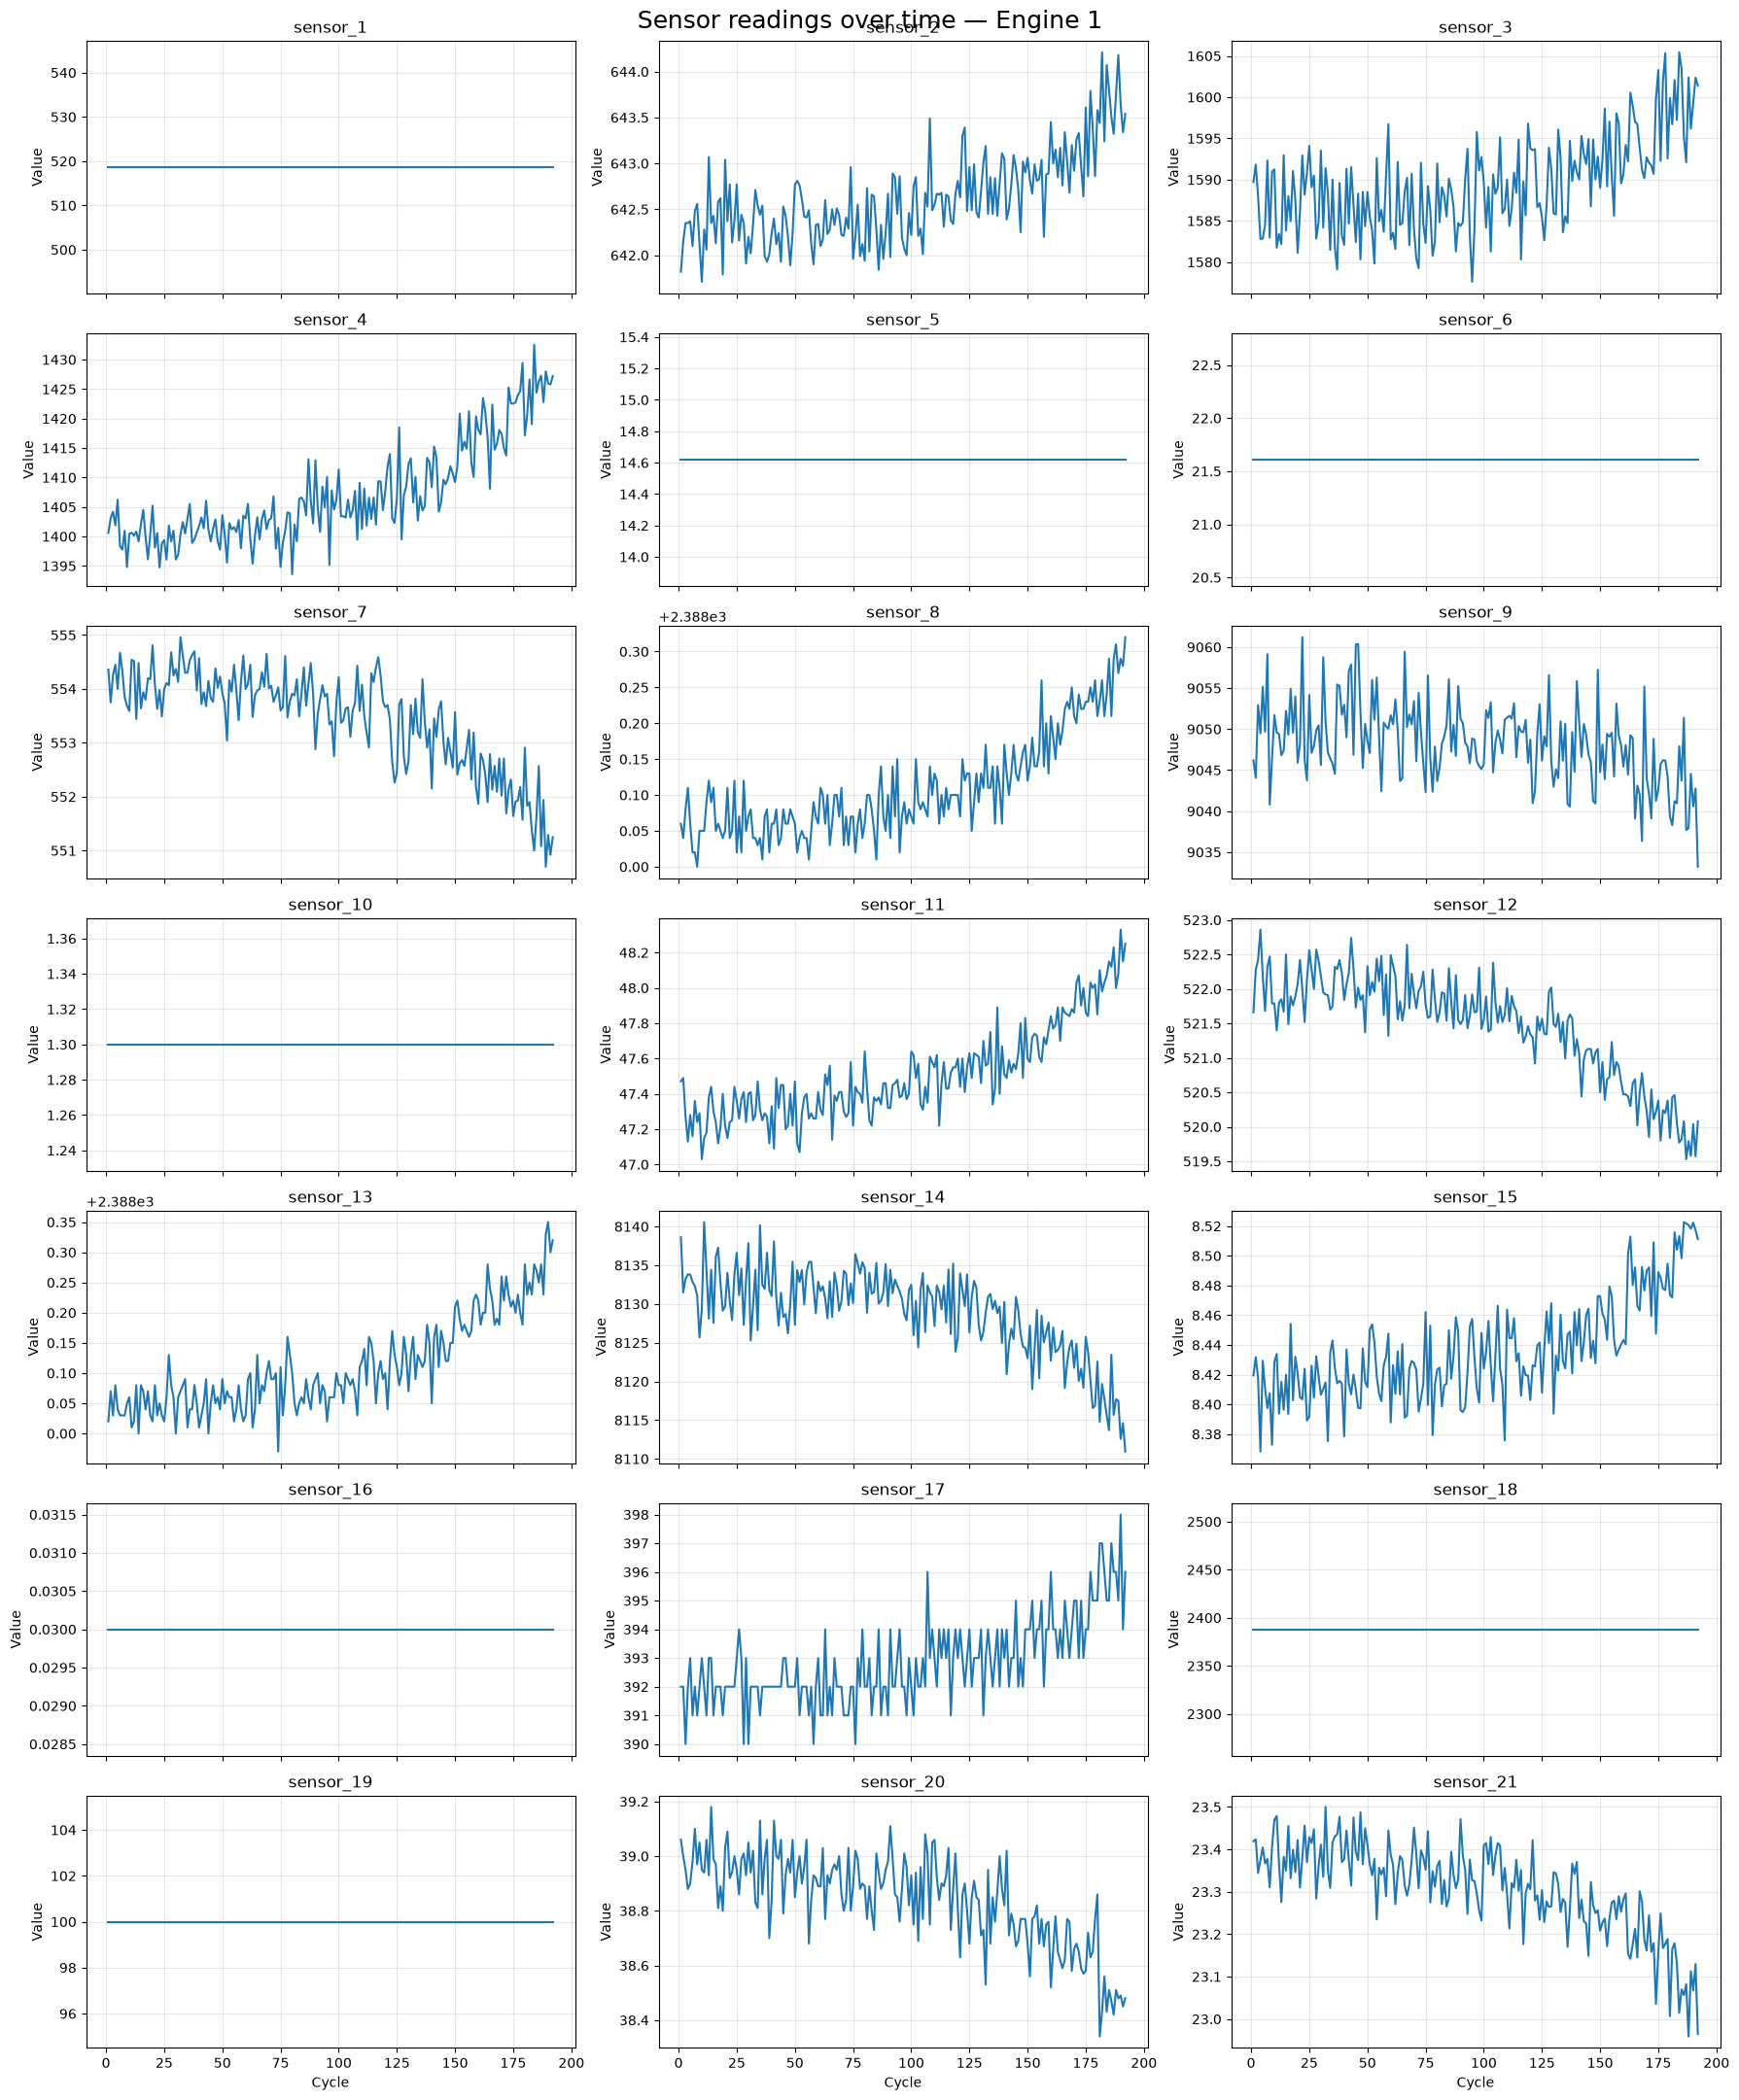

In [135]:
plot_all_sensors(df, 1)

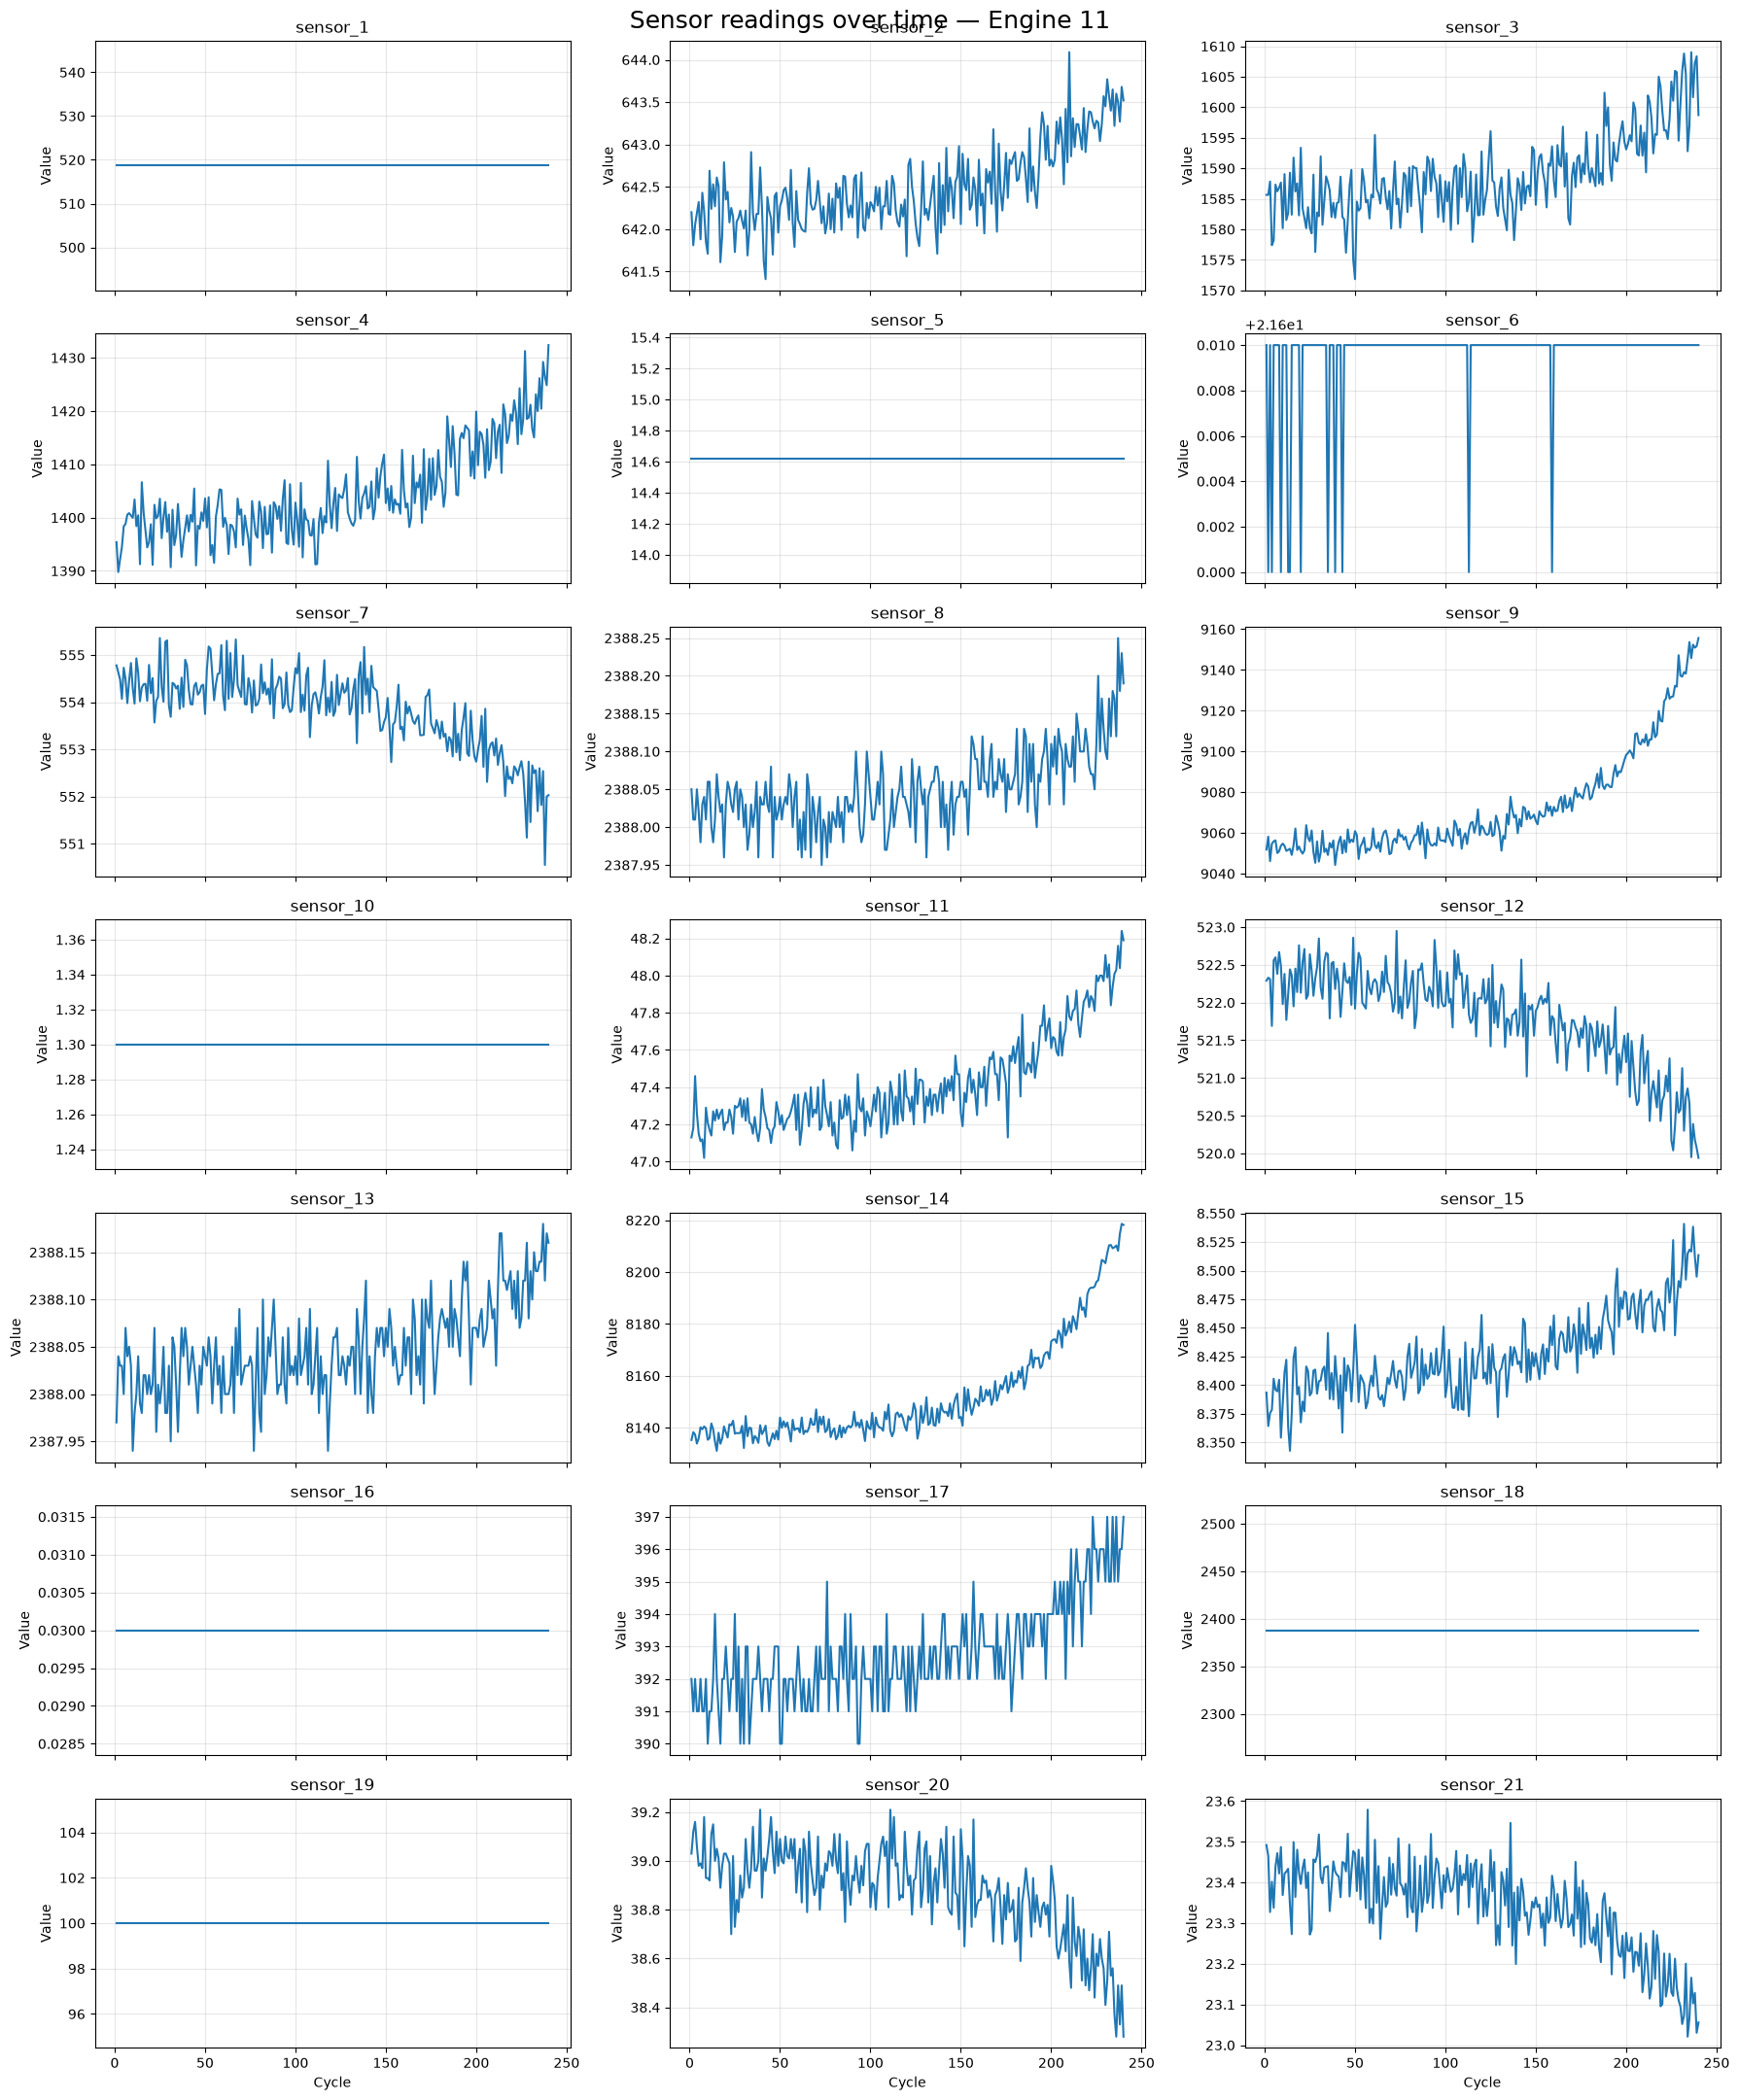

In [136]:
plot_all_sensors(df, 11)


In [137]:
correlations = (
    df.select_dtypes(include="number")
      .corr()["rul"]
      .sort_values()
)

correlations

cycle       -0.736241
sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
setting_1   -0.003198
setting_2   -0.001948
engine_id    0.078753
max_cycle    0.363152
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
rul          1.000000
setting_3         NaN
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: rul, dtype: float64

In [138]:
unique_counts = df.nunique().sort_values()
unique_counts

sensor_18       1
sensor_10       1
setting_3       1
sensor_1        1
sensor_19       1
sensor_16       1
sensor_5        1
sensor_6        2
setting_2      13
sensor_17      13
sensor_8       53
sensor_13      56
max_cycle      66
engine_id     100
sensor_20     120
setting_1     158
sensor_11     159
sensor_2      310
rul           362
cycle         362
sensor_12     427
sensor_7      513
sensor_15    1918
sensor_3     3012
sensor_4     4051
sensor_21    4745
sensor_14    6078
sensor_9     6403
dtype: int64

In [139]:
constant_columns = unique_counts[unique_counts==1].index.to_list()
constant_columns

['sensor_18',
 'sensor_10',
 'setting_3',
 'sensor_1',
 'sensor_19',
 'sensor_16',
 'sensor_5']

In [140]:
df_model = df.drop(columns=constant_columns).copy()

In [141]:
df_model.shape

(20631, 21)

In [142]:
from sklearn.model_selection import train_test_split
engine_ids = df_model['engine_id'].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=.2,
    random_state=42,
)

train_df = df_model[df_model['engine_id'].isin(train_engines)].copy()
val_df = df_model[df_model['engine_id'].isin(val_engines)].copy()

In [143]:
len(train_engines), len(val_engines), set(train_engines).intersection(set(val_engines))

(80, 20, set())

In [144]:
df_model

,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,rul
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,...,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,200,4
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,...,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,200,3
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,...,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,200,2
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,...,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,200,1


In [145]:
exclude_columns = ['engine_id', 'rul', 'max_cycle']
feature_columns = [
    col 
    for col in train_df.columns
    if col not in exclude_columns
]

In [146]:
X_train = train_df[feature_columns]
y_train = train_df['rul']

X_val = val_df[feature_columns]
y_val = val_df['rul']

In [147]:
X_train.shape, y_val.shape

((16561, 18), (4070,))

In [148]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [149]:
X_train_scaled.shape

(16561, 18)

In [150]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[-26.73, -0.36, 1.01,..., -1.54, 1.56, 2.84]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,108.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(18)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](18,)","[396.57,189.38,129.67,..., 53.45, 49.32, 21.45]"


In [151]:
val_predictions = linear_model.predict(X_val_scaled)

In [152]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(
    y_val,
    val_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_predictions
    )
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  25.16
RMSE: 31.66


In [153]:
mean_rul = y_train.mean()

naive_predictions = np.full(
    len(y_val),
    mean_rul
)

naive_mae = mean_absolute_error(
    y_val,
    naive_predictions
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        naive_predictions
    )
)

print(f"Naive MAE:  {naive_mae:.2f}")
print(f"Naive RMSE: {naive_rmse:.2f}")

Naive MAE:  55.36
Naive RMSE: 65.72


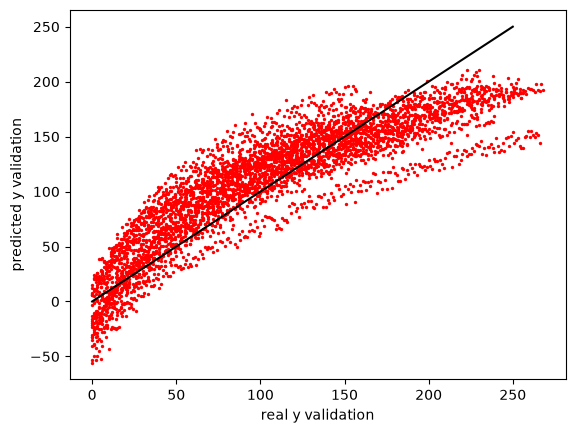

In [154]:
plt.scatter(y_val, val_predictions, s=2, c='r')
plt.xlabel('real y validation')
plt.ylabel('predicted y validation')
plt.plot([0,250],[0,250], c='black')


In [155]:
results = val_df[
    ["engine_id", "cycle", "rul"]
].copy()
"""Validation dataframe with "engine_id", "cycle", "rul" columns only.\n
    More columns can be added to this like "predicted_rul"
"""


results["predicted_rul"] = val_predictions
results["error"] = (
    results["predicted_rul"] - results["rul"]
)

results.head(20)

,engine_id,cycle,rul,predicted_rul,error
0,1,1,191,179.220919,-11.779081
1,1,2,190,175.283498,-14.716502
2,1,3,189,184.369681,-4.630319
3,1,4,188,192.278505,4.278505
4,1,5,187,176.588307,-10.411693
5,1,6,186,190.235278,4.235278
6,1,7,185,182.653471,-2.346529
7,1,8,184,186.769303,2.769303
8,1,9,183,186.103556,3.103556
9,1,10,182,185.683832,3.683832


In [156]:
results["absolute_error"] = results["error"].abs()

results.sort_values(
    "absolute_error",
    ascending=False
).head(20)

,engine_id,cycle,rul,predicted_rul,error,absolute_error
16885,84,1,266,143.930351,-122.069649,122.069649
16895,84,11,256,140.067722,-115.932278,115.932278
16896,84,12,255,139.901459,-115.098541,115.098541
16886,84,2,265,151.815264,-113.184736,113.184736
16888,84,4,263,150.004548,-112.995452,112.995452
16897,84,13,254,141.489953,-112.510047,112.510047
16889,84,5,262,151.316883,-110.683117,110.683117
16887,84,3,264,153.410984,-110.589016,110.589016
16891,84,7,260,149.413443,-110.586557,110.586557
16906,84,22,245,137.150961,-107.849039,107.849039


In [157]:
pd.DataFrame(val_df.groupby("engine_id"))

,0,1
0,1,engine_id cycle setting_1 setting_2 s...
1,5,engine_id cycle setting_1 setting_2 ...
2,11,engine_id cycle setting_1 setting_2 ...
3,13,engine_id cycle setting_1 setting_2 ...
4,19,engine_id cycle setting_1 setting_2 ...
5,23,engine_id cycle setting_1 setting_2 ...
6,31,engine_id cycle setting_1 setting_2 ...
7,32,engine_id cycle setting_1 setting_2 ...
8,34,engine_id cycle setting_1 setting_2 ...
9,40,engine_id cycle setting_1 setting_2 ...


In [158]:
val_df.sort_values('rul', ascending=False)

,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,rul
847,5,1,0.0031,0.0002,641.77,1583.59,1395.26,21.61,554.39,2387.98,...,47.19,522.34,2388.00,8152.22,8.4102,393,38.98,23.4468,269,268
848,5,2,0.0002,0.0003,642.42,1589.69,1394.88,21.61,555.57,2388.01,...,47.09,522.60,2387.99,8153.04,8.4053,392,39.12,23.4075,269,267
849,5,3,0.0002,-0.0005,642.07,1582.45,1396.29,21.61,554.49,2388.01,...,47.11,522.85,2388.02,8148.42,8.3990,393,39.18,23.3298,269,266
16885,84,1,0.0007,0.0002,643.21,1582.28,1411.05,21.61,552.34,2388.13,...,47.70,521.74,2388.17,8126.26,8.4379,393,38.69,23.2347,267,266
16886,84,2,0.0013,0.0001,643.03,1590.29,1405.09,21.61,552.78,2388.11,...,47.59,521.42,2388.21,8130.41,8.4355,391,38.86,23.3061,267,265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2375,11,240,0.0002,0.0001,643.52,1598.71,1432.38,21.61,552.03,2388.19,...,48.19,519.94,2388.16,8218.20,8.5135,397,38.28,23.0558,240,0
15753,78,231,-0.0010,0.0001,643.23,1596.60,1428.33,21.61,551.60,2388.24,...,48.22,519.11,2388.21,8160.80,8.5254,396,38.25,23.1260,231,0
1115,5,269,0.0022,0.0003,643.46,1597.28,1430.74,21.61,550.77,2388.18,...,48.26,519.86,2388.16,8212.75,8.5209,397,38.45,23.0296,269,0
16377,81,240,-0.0026,-0.0003,644.01,1601.01,1423.61,21.61,550.75,2388.28,...,48.12,519.48,2388.22,8129.61,8.4922,397,38.37,23.0289,240,0


(array([488., 496., 443., 443., 417., 352., 306., 275., 236., 163., 115.,
         94.,  73.,  47.,  41.,  21.,   7.,  10.,   9.,   7.,   6.,  10.,
          5.,   5.,   1.]),
 array([1.15252621e-03, 4.88389240e+00, 9.76663227e+00, 1.46493721e+01,
        1.95321120e+01, 2.44148519e+01, 2.92975918e+01, 3.41803316e+01,
        3.90630715e+01, 4.39458114e+01, 4.88285513e+01, 5.37112911e+01,
        5.85940310e+01, 6.34767709e+01, 6.83595108e+01, 7.32422506e+01,
        7.81249905e+01, 8.30077304e+01, 8.78904703e+01, 9.27732101e+01,
        9.76559500e+01, 1.02538690e+02, 1.07421430e+02, 1.12304170e+02,
        1.17186910e+02, 1.22069649e+02]),
 <BarContainer object of 25 artists>)

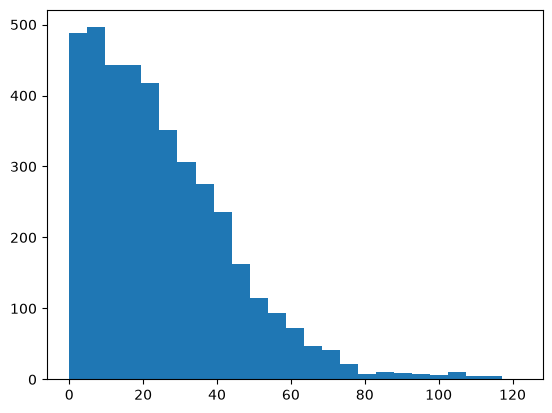

In [159]:
plt.hist(results.error.abs(), bins=25)

In [160]:
def add_rolling_features(
        df,
        window = 30,
):
    """
    Adding rolling temporat features for each sensor, for each engine
    """
    df = df.copy()

    sensor_columns = [
        col for col in df.columns
        if col.startswith('sensor_')
    ]

    grouped = df.groupby('engine_id', group_keys=False)

    for sensor in sensor_columns:
        # Creates a rolling window object for one/current sensor
        rolling = grouped[sensor].rolling(
            window=window,
            min_periods=1,
        )
        """
        Creates a rolling window object for one/current sensor
        """

        df[f"{sensor}_mean_{window}"] = (
            rolling.mean()
            .reset_index(level=0, drop=True)
        )

        df[f"{sensor}_std_{window}"] = (
            rolling.std()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

        df[f"{sensor}_min_{window}"] = (
            rolling.min()
            .reset_index(level=0, drop=True)
        )

        df[f"{sensor}_max_{window}"] = (
            rolling.max()
            .reset_index(level=0, drop=True)
        )

        # Difference between current value and value 29 cycles ago.
        df[f"{sensor}_change_{window}"] = (
            grouped[sensor]
            .diff(periods=window - 1)
            .fillna(0)
        )

    return df

In [161]:
train_df_features = add_rolling_features(
    train_df,
    window=30
)

val_df_features = add_rolling_features(
    val_df,
    window=30
)


In [162]:
train_df.shape, train_df_features.shape

((16561, 21), (16561, 96))

In [163]:
train_df_features


,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_20_mean_30,sensor_20_std_30,sensor_20_min_30,sensor_20_max_30,sensor_20_change_30,sensor_21_mean_30,sensor_21_std_30,sensor_21_min_30,sensor_21_max_30,sensor_21_change_30
192,2,1,-0.0018,0.0006,641.89,1583.84,1391.28,21.60,554.53,2388.01,...,38.940000,0.000000,38.94,38.94,0.00,23.458500,0.000000,23.4585,23.4585,0.0000
193,2,2,0.0043,-0.0003,641.82,1587.05,1393.13,21.61,554.77,2387.98,...,39.000000,0.084853,38.94,39.06,0.00,23.433500,0.035355,23.4085,23.4585,0.0000
194,2,3,0.0018,0.0003,641.55,1588.32,1398.96,21.60,555.14,2388.04,...,39.036667,0.087369,38.94,39.11,0.00,23.430667,0.025477,23.4085,23.4585,0.0000
195,2,4,0.0035,-0.0004,641.68,1584.15,1396.08,21.61,554.25,2387.98,...,39.060000,0.085245,38.94,39.13,0.00,23.448675,0.041592,23.4085,23.5027,0.0000
196,2,5,0.0005,0.0004,641.73,1579.03,1402.52,21.60,555.12,2388.03,...,39.084000,0.091269,38.94,39.18,0.00,23.443620,0.037752,23.4085,23.5027,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,...,38.529667,0.136899,38.14,38.81,-0.12,23.138527,0.073789,22.9735,23.2625,-0.2540
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,...,38.519333,0.142222,38.14,38.81,-0.31,23.136257,0.071983,22.9735,23.2625,-0.1031
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,...,38.513667,0.141871,38.14,38.81,-0.27,23.125283,0.076992,22.9333,23.2345,-0.2828
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,...,38.499667,0.142550,38.14,38.81,-0.34,23.120213,0.075805,22.9333,23.2345,-0.0923


In [164]:
excluded_columns = [
    "engine_id",
    "max_cycle",
    "rul",
]

feature_columns_rolling = [
    col
    for col in train_df_features.columns
    if col not in excluded_columns
]

X_train_rolling = train_df_features[
    feature_columns_rolling
]

y_train_rolling = train_df_features["rul"]

X_val_rolling = val_df_features[
    feature_columns_rolling
]

y_val_rolling = val_df_features["rul"]

In [165]:
rolling_scaler = StandardScaler()

X_train_rolling_scaled = rolling_scaler.fit_transform(
    X_train_rolling
)

X_val_rolling_scaled = rolling_scaler.transform(
    X_val_rolling
)

In [166]:
linear_model_rolling = LinearRegression()
linear_model_rolling.fit(
    X_train_rolling_scaled,
    y_train_rolling
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](93,)","[-22.05, -0.37, 0.94,...,-13.58, 2.12, 1.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,108.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,93
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(93)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](93,)","[856.33,440.06,262.71,..., 8.81, 7.24, 4.87]"


In [167]:
rolling_predictions = linear_model_rolling.predict(
    X_val_rolling_scaled
)

In [168]:
rolling_mae = mean_absolute_error(
    y_val_rolling,
    rolling_predictions
)

rolling_rmse = np.sqrt(
    mean_squared_error(
        y_val_rolling,
        rolling_predictions
    )
)

print(f"Rolling Linear MAE:  {rolling_mae:.2f}")
print(f"Rolling Linear RMSE: {rolling_rmse:.2f}")

Rolling Linear MAE:  26.29
Rolling Linear RMSE: 32.61


(np.float64(-13.4),
 np.float64(281.4),
 np.float64(-87.50203512425131),
 np.float64(375.8964634341154))

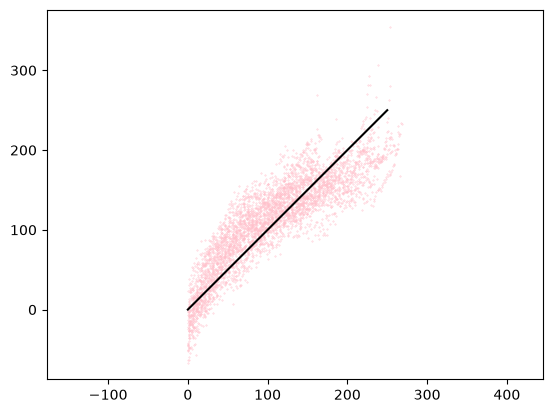

In [169]:
plt.scatter(y_val_rolling, rolling_predictions, c='pink', s=.1)
plt.plot([0,250],[0,250],c='black')
plt.axis('equal')

In [170]:
2

2

In [171]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=.05,
    max_leaf_nodes=31,
    random_state=42,
)

gb_model.fit(
    X_train_rolling,
    y_train_rolling,
)

gb_predictions = gb_model.predict(
    X_val_rolling
)

In [172]:
gb_mae = mean_absolute_error(
    y_val_rolling,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_val_rolling,
        gb_predictions
    )
)

print(f"Gradient Boosting MAE:  {gb_mae:.2f}")
print(f"Gradient Boosting RMSE: {gb_rmse:.2f}")

Gradient Boosting MAE:  23.92
Gradient Boosting RMSE: 32.43


(np.float64(-13.4),
 np.float64(281.4),
 np.float64(-18.111895376941114),
 np.float64(293.56365381356534))

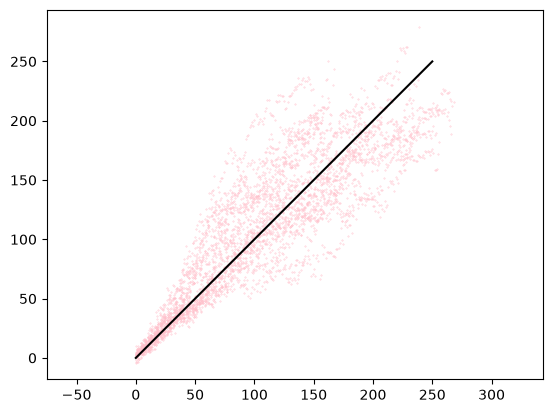

In [173]:
plt.scatter(y_val_rolling, gb_predictions, c='pink', s=.1)
plt.plot([0,250],[0,250],c='black')
plt.axis('equal')

## Adding cap when RUL is too high

We can't magically predict two healthy engine's that one has 200 cycles left and other one has 160

In [174]:
RUL_CAP = 125

df_model["rul_capped"] = df_model["rul"].clip(
    upper=RUL_CAP
)

train_df["rul_capped"] = train_df["rul"].clip(
    upper=RUL_CAP
)

val_df["rul_capped"] = val_df["rul"].clip(
    upper=RUL_CAP
)

train_df_features["rul_capped"] = (
    train_df_features["rul"].clip(upper=RUL_CAP)
)

val_df_features["rul_capped"] = (
    val_df_features["rul"].clip(upper=RUL_CAP)
)

In [175]:
excluded_columns = [
    "engine_id",
    "max_cycle",
    "rul",
    "rul_capped",
]

feature_columns_rolling = [
    col
    for col in train_df_features.columns
    if col not in excluded_columns
]

X_train_rolling = train_df_features[feature_columns_rolling]
X_val_rolling = val_df_features[feature_columns_rolling]

y_train_capped = train_df_features["rul_capped"]
y_val_capped = val_df_features["rul_capped"]

In [176]:
gb_model_capped = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42,
)

gb_model_capped.fit(
    X_train_rolling,
    y_train_capped,
)

gb_predictions_capped = gb_model_capped.predict(
    X_val_rolling
)

In [177]:
gb_capped_mae = mean_absolute_error(
    y_val_capped,
    gb_predictions_capped
)

gb_capped_rmse = np.sqrt(
    mean_squared_error(
        y_val_capped,
        gb_predictions_capped
    )
)

print(f"Capped Gradient Boosting MAE:  {gb_capped_mae:.2f}")
print(f"Capped Gradient Boosting RMSE: {gb_capped_rmse:.2f}")

Capped Gradient Boosting MAE:  10.14
Capped Gradient Boosting RMSE: 15.31


(np.float64(-12.5),
 np.float64(262.5),
 np.float64(-15.617182609955746),
 np.float64(262.64843726714076))

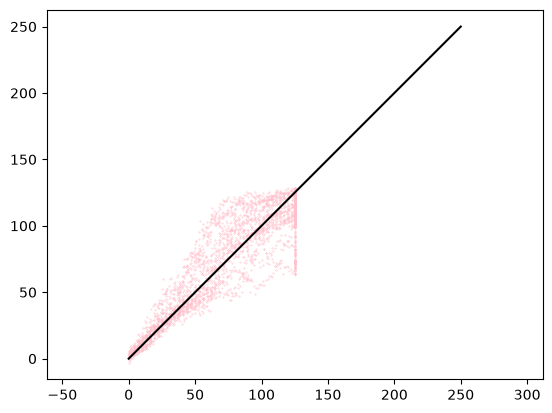

In [178]:
plt.scatter(y_val_capped, gb_predictions_capped, c='pink', s=.1)
plt.plot([0,250],[0,250],c='black')
plt.axis('equal')